#### <h2><b>Лабораторна робота №4 "Advanced Nets"</b> </h2> Зінов'єв Андрій, гр. ФБ-42мп

1.  Завдання щодо генерації текстів або машинного перекладу (на вибір) на базі рекурентних мереж або трансформерів (на вибір). 
Вирішіть завдання щодо генерації текстів або машинного перекладу. Особливо вітаються україномовні моделі.

 У ході роботи використано ресурс: https://www.manythings.org/anki/ukr-eng.zip та приклад https://keras.io/examples/nlp/lstm_seq2seq/ , як основа алгоритму:

In [17]:
import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense

# Задамо початкові параметри для навчання мережі
batch_size, epochs, latent_dim, max_samples = 64, 200, 256, 10000

# Відкриваємо файл з словником
with open("ukr.txt", "r", encoding="utf-8") as f:
    lines = f.read().strip().split("\n")

# Подготовка текстів
input_texts, output_texts = [], []
input_chars, output_chars = set(), set()

for line in lines[:max_samples]:
    if len(parts := line.split("\t")) < 2: continue
    eng, ukr = parts[:2]
    ukr = f"\t{ukr}\n"  # Додаємо символи початку, кінця строк
    input_texts.append(eng)
    output_texts.append(ukr)
    input_chars.update(eng)
    output_chars.update(ukr)

# Сортування символів та знайдення оптимальних параметрів для подальшої роботи
input_chars, output_chars = sorted(input_chars), sorted(output_chars)
num_input_tokens, num_output_tokens = len(input_chars), len(output_chars)
max_input_len, max_output_len = max(map(len, input_texts)), max(map(len, output_texts))

# Словники для індексації
input_char_to_idx = {char: i for i, char in enumerate(input_chars)}
output_char_to_idx = {char: i for i, char in enumerate(output_chars)}

# Масиви one-hot
encoder_input_data = np.zeros((len(input_texts), max_input_len, num_input_tokens), dtype="float32")
decoder_input_data = np.zeros((len(input_texts), max_output_len, num_output_tokens), dtype="float32")
decoder_target_data = np.zeros((len(input_texts), max_output_len, num_output_tokens), dtype="float32")

for i, (input_text, output_text) in enumerate(zip(input_texts, output_texts)):
    for t, char in enumerate(input_text): encoder_input_data[i, t, input_char_to_idx[char]] = 1.0
    for t, char in enumerate(output_text):
        decoder_input_data[i, t, output_char_to_idx[char]] = 1.0
        if t > 0: decoder_target_data[i, t - 1, output_char_to_idx[char]] = 1.0

# Створимо модель кодувальника (кодера)
encoder_inputs = Input(shape=(None, num_input_tokens))
encoder_lstm = LSTM(latent_dim, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Відповідно створимо і декодерську модель
decoder_inputs = Input(shape=(None, num_output_tokens))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(num_output_tokens, activation="softmax")
decoder_outputs = decoder_dense(decoder_outputs)



In [18]:
# Ініціалізація загальної моделі
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# "Скормлюємо" даними
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
model.fit([encoder_input_data, decoder_input_data], decoder_target_data,
          batch_size=batch_size, epochs=epochs, validation_split=0.2)


Epoch 1/200


C:\Users\azin0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_63', 'keras_tensor_67']. Received: the structure of inputs=('*', '*')
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.0354 - loss: 1.1092 - val_accuracy: 0.0434 - val_loss: 1.0412
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0458 - loss: 0.9668 - val_accuracy: 0.0411 - val_loss: 1.0388
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0457 - loss: 0.9642 - val_accuracy: 0.0427 - val_loss: 1.0342
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0464 - loss: 0.9521 - val_accuracy: 0.0436 - val_loss: 1.0330
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0494 - loss: 0.9384 - val_accuracy: 0.0547 - val_loss: 1.0229
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0530 - loss: 0.9288 - val_accuracy: 0.0553 - val_loss: 1.0118
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.0560 - loss: 0.9220 - val_accuracy: 0.0605 - val_loss: 0.9887
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.0577 - loss: 0.9150 - val_

In [20]:
# Ініціалізація інференс моделі кодувальника
encoder_model = Model(encoder_inputs, encoder_states)

# Ініціалізація інференс моделі декодеру
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
decoder_lstm_outputs, state_h, state_c = decoder_lstm(decoder_inputs, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_lstm_outputs)
decoder_model = Model([decoder_inputs] + decoder_states_inputs, [decoder_outputs] + decoder_states)

# Функція декодування в текст
reverse_input_char_idx = {i: char for char, i in input_char_to_idx.items()}
reverse_output_char_idx = {i: char for char, i in output_char_to_idx.items()}

def decode_sequence(input_seq):
    # Стан кодувальника
    states_value = encoder_model.predict(input_seq, verbose=0)
    
    target_seq = np.zeros((1, 1, num_output_tokens))
    target_seq[0, 0, output_char_to_idx["\t"]] = 1.0
    
    stop_condition, decoded_sentence = False, ""
    while not stop_condition:
        # Отримання інференційованих значень
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        
        # Декодуємо символи
        sampled_token_idx = np.argmax(output_tokens[0, -1, :])
        sampled_char = reverse_output_char_idx[sampled_token_idx]
        decoded_sentence += sampled_char
        
        # Вихід з циклу (умова)
        if sampled_char == "\n" or len(decoded_sentence) > max_output_len:
            stop_condition = True
        
        # Оновлюємо значення послідовності
        target_seq = np.zeros((1, 1, num_output_tokens))
        target_seq[0, 0, sampled_token_idx] = 1.0
        
        # Оновлюємо стан кодувальника
        states_value = [h, c]
    
    return decoded_sentence


# Декодування тексту (20 тестів)
counter = 1
for seq_index in range(20):
    input_seq = encoder_input_data[seq_index: seq_index + 1]
    decoded_sentence = decode_sequence(input_seq)
    print(f"Test №{counter}:")
    print(f"  Input string: {input_texts[seq_index]}")
    print(f"  Decoded string: {decoded_sentence}")
    counter += 1


C:\Users\azin0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['keras_tensor_67', 'keras_tensor_78', 'keras_tensor_79']. Received: the structure of inputs=('*', '*', '*')
  warnings.warn(


Test №1:
  Input string: Go.
  Decoded string: Поо....................................................
Test №2:
  Input string: Hi.
  Decoded string: Привии.................................................
Test №3:
  Input string: Hi.
  Decoded string: Привии.................................................
Test №4:
  Input string: Hi.
  Decoded string: Привии.................................................
Test №5:
  Input string: Run!
  Decoded string: Сірии..................................................
Test №6:
  Input string: Run!
  Decoded string: Сірии..................................................
Test №7:
  Input string: Run!
  Decoded string: Сірии..................................................
Test №8:
  Input string: Wow!
  Decoded string: Поо....................................................
Test №9:
  Input string: Wow!
  Decoded string: Поо....................................................
Test №10:
  Input string: Wow!
  Decoded string: Поо................

2. Проведіть експерименти з моделями бібліотеки Hugging Face (раніше - Hugging Face Transformers, https://huggingface.co/) за допомогою (наприклад) Pipeline модуля.

   Для виконання завдання було обрано модуль sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 (https://huggingface.co/sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2) який робить векторні представлення з тексту українською мовою. А потім мій алгоритм, щоб застосувати ці представлення: читає файл драми-феєрії "Лісова пісня", та за допомогою косинусної подібності знаходить схожі фрагменти тексту.

In [1]:
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.metrics.pairwise import cosine_similarity

# Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]  # First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Завантаження моделі з Hugging Face Hub
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
model = AutoModel.from_pretrained('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

C:\Users\azin0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\azin0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [6]:
# Зчитування тексту казки "Лісова пісня"
with open('Lisova_pisnya_1371650989.txt', 'r', encoding='utf-8') as file:
    corpus = file.readlines()

# Токенізація та обчислення embeddings для кожного рядка тексту казки
encoded_input_corpus = tokenizer(corpus, padding=True, truncation=True, return_tensors='pt', max_length=512)
with torch.no_grad():
    model_output_corpus = model(**encoded_input_corpus)

# Виконання mean pooling для кожного тексту в корпусі (казці)
corpus_embeddings = mean_pooling(model_output_corpus, encoded_input_corpus['attention_mask'])

# Запити для пошуку схожих текстів (твердження)
queries = [
    "Мавка є символом чистоти і глибоких почуттів.",
    "Ліс в казці є не лише місцем, а й важливим персонажем.",
    "Кохання Мавки та Лукаша — це ключова тема твору.",
    "Лісовий є захисником лісу і носієм його таємниць.",
    "Конфлікт між природою і людиною є основним у казці.",
    "Мавка прагне гармонії між людьми і природою.",
    "Казка піднімає тему взаємодії з природними духами.",
    "Природа в казці є відображенням внутрішнього світу героїв.",
    "Людина і природа в казці перебувають у постійній боротьбі.",
    "Розв'язка казки символізує перемогу природи над людськими амбіціями."
]

# Обчислення embeddings для кожного запиту
query_embeddings = []
for query in queries:
    encoded_input_query = tokenizer([query], padding=True, truncation=True, return_tensors='pt', max_length=512)
    with torch.no_grad():
        model_output_query = model(**encoded_input_query)
    query_embedding = mean_pooling(model_output_query, encoded_input_query['attention_mask'])
    query_embeddings.append(query_embedding)

# Обчислення косинусної подібності між запитами та кожним рядком тексту казки
for query, query_embedding in zip(queries, query_embeddings):
    similarities = cosine_similarity(query_embedding, corpus_embeddings)
    most_similar_index = similarities.argmax()
    
    print(f"Запит: {query}")
    print(f"Найбільш схоже речення з казки 'Лісова пісня': {corpus[most_similar_index]}")
    print()


Запит: Мавка є символом чистоти і глибоких почуттів.
Найбільш схоже речення з казки 'Лісова пісня':            із глибокості...


Запит: Ліс в казці є не лише місцем, а й важливим персонажем.
Найбільш схоже речення з казки 'Лісова пісня': А ясень їй киває в верховітті:


Запит: Кохання Мавки та Лукаша — це ключова тема твору.
Найбільш схоже речення з казки 'Лісова пісня': стає мов камінь. От  м о є  кохання! 


Запит: Лісовий є захисником лісу і носієм його таємниць.
Найбільш схоже речення з казки 'Лісова пісня': і лісових великих таємниць. 


Запит: Конфлікт між природою і людиною є основним у казці.
Найбільш схоже речення з казки 'Лісова пісня': (малі, заморені істоти, в лахмітті, з вічним гризьким голодом на обличчі, 


Запит: Мавка прагне гармонії між людьми і природою.
Найбільш схоже речення з казки 'Лісова пісня': душа така саміська, як і наша.


Запит: Казка піднімає тему взаємодії з природними духами.
Найбільш схоже речення з казки 'Лісова пісня': бо в тебе дух не вільний лісов

3. Завдання щодо генерації або стилізації зображень (на вибір)
Вирішіть завдання перенесення стилю або генерації зображень (архітектура за вашим вибором: GAN/DCGAN/VAE/Diffusion).

Основа алгоритму полягає у використанні тих самий принципів що і у https://keras.io/examples/generative/neural_style_transfer/

In [46]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as tf_image
from tensorflow.keras import models
import os
import time

# Завантаження зображень та попередня обробка
def load_and_process_img(img_path):
    img = tf_image.load_img(img_path, target_size=(400, 400))
    img = tf_image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = tf.keras.applications.vgg19.preprocess_input(img)
    return img

# Відновлення зображення 
def deprocess_img(processed_img):
    processed_img = processed_img.squeeze()
    processed_img = processed_img + np.array([103.939, 116.779, 123.68])
    processed_img = processed_img[:, :, ::-1]  # Convert from BGR to RGB
    processed_img = np.clip(processed_img, 0, 255).astype('uint8')
    return processed_img

# Використання моделі VGG19 для визначення фіч картинки
def get_model():
    vgg = tf.keras.applications.VGG19(weights='imagenet', include_top=False)
    vgg.trainable = False
    
    # Визначаємо шари
    model_layers = [
        'block1_conv2', 'block2_conv2', 'block3_conv2', 'block4_conv2', 'block5_conv2'
    ]
    
    model_outputs = [vgg.get_layer(layer).output for layer in model_layers]
    model = models.Model(inputs=vgg.input, outputs=model_outputs)
    
    return model

# Обчислення значень лосу (втрати) змісту зображень, стилю
def content_loss(content, combination):
    return tf.reduce_sum(tf.square(combination - content))

def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.linalg.matmul(x, x, transpose_a=True)

def style_loss(style, combination):
    s = gram_matrix(style)
    c = gram_matrix(combination)
    return tf.reduce_sum(tf.square(s - c))

# Визначення градієнту та втрат
def compute_loss_and_grads(combination_image, base_image, style_reference_image):
    with tf.GradientTape() as tape:
        combination_image = tf.Variable(combination_image)
        tape.watch(combination_image)

        # Витягування фіч
        model = get_model()
        base_features = model(base_image)
        style_features = model(style_reference_image)
        combination_features = model(combination_image)

        # Обчислення втрат контенту та стилю
        c_loss, s_loss, weight_content, weight_style  = 0, 0, 1.0, 1.0
        
        for base_f, comb_f in zip(base_features, combination_features):
            c_loss += content_loss(base_f, comb_f)

        for style_f, comb_f in zip(style_features, combination_features):
            s_loss += style_loss(style_f, comb_f)

        # Загальна кількість "втрат"
        loss = weight_content * c_loss + weight_style * s_loss

    grads = tape.gradient(loss, combination_image)
    return loss, grads


In [52]:
# Ініціалізуємо оптимайзер
optimizer = tf.optimizers.Adam(learning_rate=10.0)

# Визначимо для алгоритму шляхи до наших цільових картинок (ту що будемо змінювати, та стилізована картинка)
base_image_path = '2.jpg'
style_reference_image_path = 'style.jpg'

base_image = load_and_process_img(base_image_path)
style_reference_image = load_and_process_img(style_reference_image_path)

combination_image = tf.Variable(base_image)


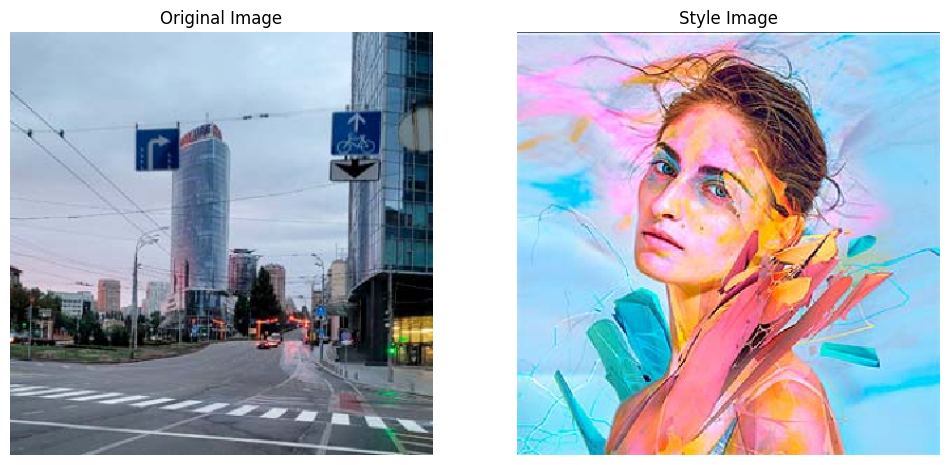

In [53]:
# Перегляд зображень перед обробкою алгоритмом
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Оригінальна картинка
original_img = deprocess_img(base_image)
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

# Картинка з якої запозичимо стиль
style_img = deprocess_img(style_reference_image)
axes[1].imshow(style_img)
axes[1].set_title("Style Image")
axes[1].axis("off")

# Виводимо
plt.show()


Iteration 1/10, Loss: 266643758446596501536768.00, Time elapsed: 10.01s


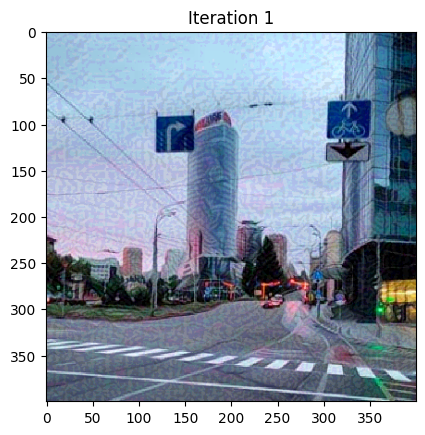

Iteration 2/10, Loss: 191163933095025254072320.00, Time elapsed: 19.50s


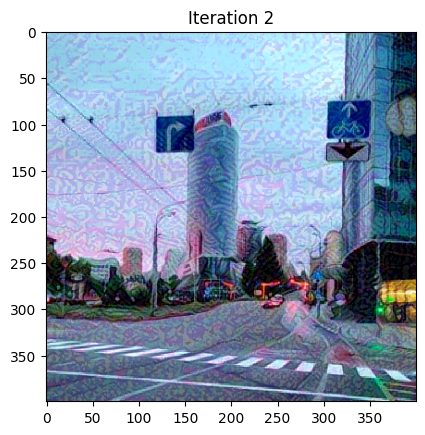

Iteration 3/10, Loss: 132777484100341705211904.00, Time elapsed: 29.02s


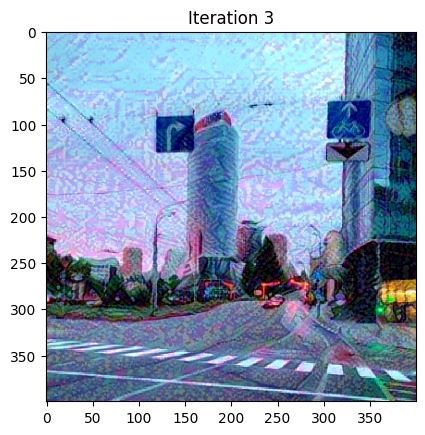

Iteration 4/10, Loss: 106362016802767269527552.00, Time elapsed: 38.75s


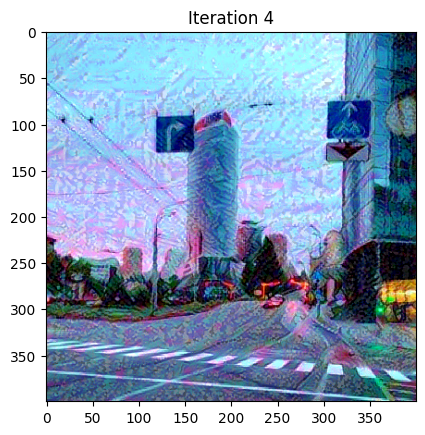

Iteration 5/10, Loss: 101985040382519922393088.00, Time elapsed: 48.22s


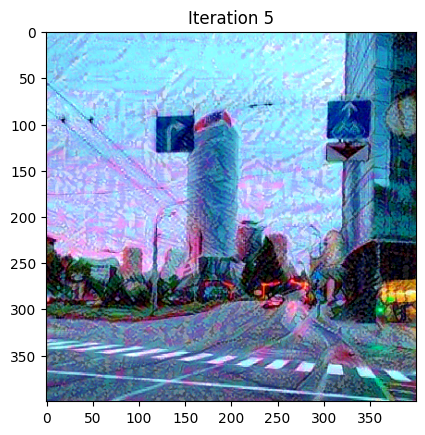

Iteration 6/10, Loss: 101719985530050659221504.00, Time elapsed: 57.61s


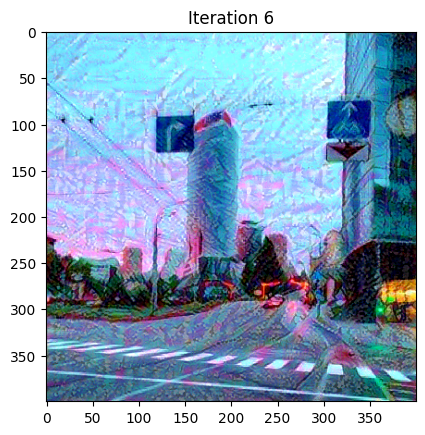

Iteration 7/10, Loss: 95833600673092326129664.00, Time elapsed: 67.31s


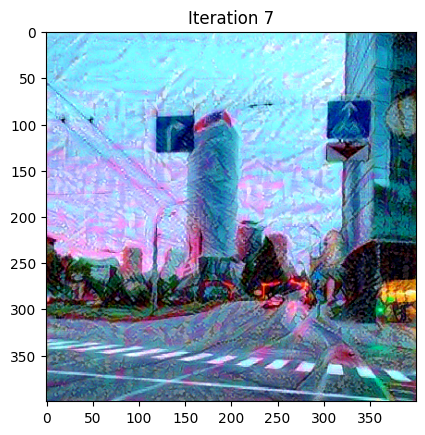

Iteration 8/10, Loss: 83323780851359459311616.00, Time elapsed: 76.01s


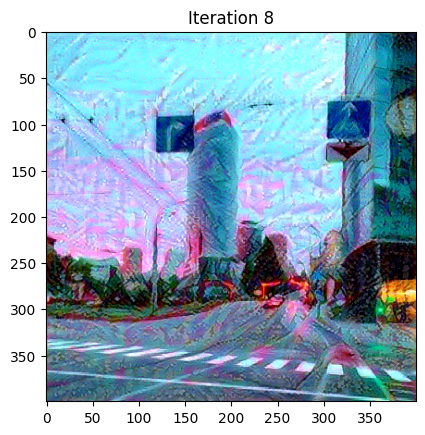

Iteration 9/10, Loss: 67840351289264165617664.00, Time elapsed: 84.78s


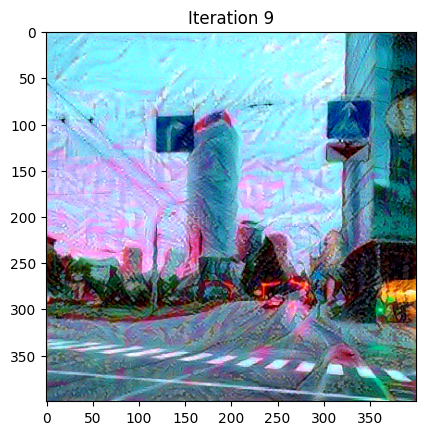

Iteration 10/10, Loss: 54118774937392483663872.00, Time elapsed: 92.95s


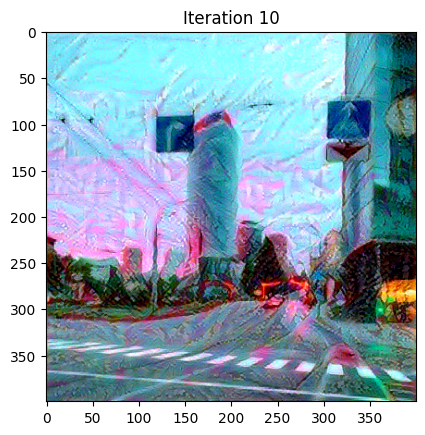

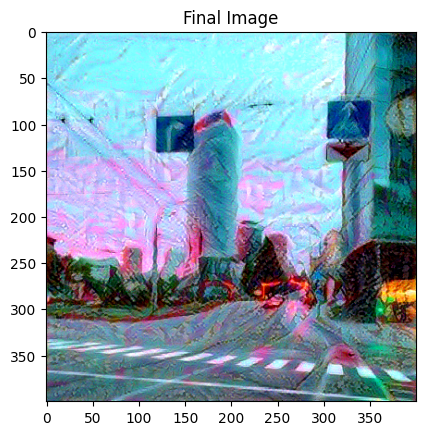

In [54]:
# Задамо кількість ітерацій (епох) для обробки
# у даному випадку 10 - тому що при більших ітераціях якість картинки стає нечитаємою
# різниці між 50 та 100 ітераціями майже не видно, та і зміст зображення гарно постраждає
iterations = 10

# Початок відліку часу - додав щоб розуміти час виконання ітерації
start_time = time.time()

# Алгоритм переносу стилю зображення
for i in range(1, iterations + 1):
    loss, grads = compute_loss_and_grads(
        combination_image, base_image, style_reference_image
    )
    
    # Застосування градієнтів до зображення-комбінації
    optimizer.apply_gradients([(grads, combination_image)])
    
    # Переглядаємо що відбулось за ітерацію, бачимо час виконання, кількість втрат та картинку
    elapsed_time = time.time() - start_time
    print(f"Iteration {i}/{iterations}, Loss: {loss.numpy():.2f}, Time elapsed: {elapsed_time:.2f}s")
    img = deprocess_img(combination_image.numpy())
    plt.imshow(img)
    plt.title(f"Iteration {i}")
    plt.show()

# Виводимо наш результат
final_img = deprocess_img(combination_image.numpy())
plt.imshow(final_img)
plt.title("Final Image")
plt.show()


Отже, бачимо що якість деталей картинки значно погіршилася, це ще можна поснити тим, що я використовував картинки ".jpg" формату. При експортуванні з фотошопу при ресайзингу, я зменшив розмір вихідного зображення до маленького (якість залишалась 30%) і стосувалась як оригінального кадру, так і стилізованого зображення. До речі, стилізоване зображення було взято з завантажувального вікна фотошопу, а оригінальний кадр був вже моїм.